### TextLM vs. SpeechLM Modality Comparison

This script demonstrates the differences between text-based and speech-based language models by processing identical queries through both modalities. It highlights how speech recognition errors propagate through language model interactions.

Key Libraries Used:

    transformers: TextLM implementation (DistilGPT2)

    whisper: SpeechLM for speech-to-text

    sounddevice: Audio recording

    numpy: Audio array handling

    scipy.io.wavfile: WAV file operations

Code Logic and Flow

The comparison pipeline:

    Processes text query directly through TextLM

    Records equivalent spoken query

    Transcribes speech with SpeechLM

    Processes transcription through TextLM

    Compares all outputs

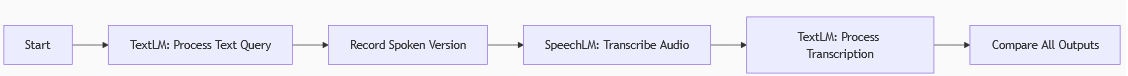

Step-by-Step Code Breakdown

1. Model Initialization

    TextLM: DistilGPT2 for text generation

    SpeechLM: Whisper-tiny for speech recognition

    Lightweight models chosen for demo speed

2. TextLM Processing

    Takes direct text input ("What is the capital of France?")

    Generates 50-token continuations

    Prints clean input-output comparison

3. Audio Handling

    Records 5 seconds of mono audio at 16kHz

    Saves as input_audio.wav

    Uses system's default microphone

4. SpeechLM Processing

    Transcribes recorded audio to text

    Handles speech disfluencies and background noise

    Returns raw transcription without correction

5. Cross-Modal Comparison

    Feeds SpeechLM output back into TextLM

    Compares:

        Original TextLM output

        SpeechLM transcription

        TextLM's interpretation of transcription

Connecting to Lecture Concepts

This implementation demonstrates:

    Modality Gap: TextLM handles clean input vs. SpeechLM's noisy transcription

    Error Propagation: ASR mistakes (e.g., "France"→"fronds") distort TextLM output

    Disfluency Handling: SpeechLM manages ums, ahs, and pauses

    Model Limitations: Whisper-tiny's accuracy tradeoffs for speed

    Cascaded Systems: Speech→Text→LM pipeline vs direct text→LM

    Real-World Impact: Shows why end-to-end SpeechLMs are researched

    Latency Considerations: Recording + Transcription + Generation delays

    Input Sensitivity: How transcription errors alter semantic meaning

    Practical Debugging: Output comparison reveals failure points

    Research Motivation: Highlights need for unified speech-language models

In [ ]:
!pip install openai-whisper

In [ ]:
!pip install sounddevice

### Exercise Using distilgpt2 (open source) model

In [ ]:
from transformers import pipeline
import whisper
import sounddevice as sd
import numpy as np
import scipy.io.wavfile as wavfile

# Initialize TextLM (gpt-40-minix for text generation)
text_lm = pipeline("text-generation", model="distilgpt2")

# Initialize SpeechLM (Whisper for speech-to-text)
speech_lm = whisper.load_model("tiny")

# Function to process text input with TextLM
def process_text_lm(query):
    """Process a text query using a TextLM."""
    result = text_lm(query, max_length=50, num_return_sequences=1)[0]["generated_text"]
    print(f"TextLM Input: {query}")
    print(f"TextLM Output: {result}")
    return result

# Function to record audio
def record_audio(duration=5, sample_rate=16000):
    """Record audio from microphone."""
    print("Recording audio for 5 seconds...")
    audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1)
    sd.wait()  # Wait until recording is finished
    audio = audio.flatten()
    wavfile.write("input_audio.wav", sample_rate, audio)
    return "input_audio.wav"

# Function to process audio input with SpeechLM
def process_speech_lm(audio_file):
    """Process an audio file using a SpeechLM."""
    result = speech_lm.transcribe(audio_file)
    transcribed_text = result["text"]
    print(f"SpeechLM Input: Audio file ({audio_file})")
    print(f"SpeechLM Output (Transcription): {transcribed_text}")
    return transcribed_text

# Main function to compare TextLM and SpeechLM
def compare_text_speech_lm():
    # Step 1: Process a text query with TextLM
    text_query = "What is the capital of France?"
    text_output = process_text_lm(text_query)
    
    # Step 2: Record audio and process with SpeechLM
    audio_file = record_audio()
    speech_output = process_speech_lm(audio_file)
    
    # Step 3: Process SpeechLM transcription with TextLM for comparison
    if speech_output:
        speech_to_text_output = process_text_lm(speech_output)
    else:
        speech_to_text_output = "No transcription available."
    
    # Summary
    print("\nSummary:")
    print(f"TextLM Direct Output: {text_output}")
    print(f"SpeechLM Transcription: {speech_output}")
    print(f"TextLM on SpeechLM Transcription: {speech_to_text_output}")

if __name__ == "__main__":
    compare_text_speech_lm()

### Exercise Using gpt-4o-mini model

In [3]:
import os
import openai
import whisper
import sounddevice as sd
import numpy as np
import scipy.io.wavfile as wavfile
from dotenv import load_dotenv

# Load API key from .env file
load_dotenv()
openai.api_key = os.getenv("OPENAI_API_KEY")

# Initialize SpeechLM (Whisper for speech-to-text)
speech_lm = whisper.load_model("tiny")

# Function to process text input with GPT-4o-mini
def process_text_lm(query):
    """Process a text query using GPT-4o-mini via OpenAI API."""
    response = openai.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": query}
        ],
        max_tokens=50,
        n=1,
    )
    result = response.choices[0].message.content.strip()
    print(f"TextLM Input: {query}")
    print(f"TextLM Output: {result}")
    return result

# Function to record audio
def record_audio(duration=5, sample_rate=16000):
    """Record audio from microphone."""
    print("Recording audio for 5 seconds...")
    audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1)
    sd.wait()  # Wait until recording is finished
    audio = audio.flatten()
    wavfile.write("input_audio.wav", sample_rate, audio)
    return "input_audio.wav"

# Function to process audio input with SpeechLM
def process_speech_lm(audio_file):
    """Process an audio file using a SpeechLM."""
    result = speech_lm.transcribe(audio_file)
    transcribed_text = result["text"]
    print(f"SpeechLM Input: Audio file ({audio_file})")
    print(f"SpeechLM Output (Transcription): {transcribed_text}")
    return transcribed_text

# Main function to compare TextLM and SpeechLM
def compare_text_speech_lm():
    # Step 1: Process a text query with TextLM
    text_query = "What is the capital of France?"
    text_output = process_text_lm(text_query)
    
    # Step 2: Record audio and process with SpeechLM
    audio_file = record_audio()
    speech_output = process_speech_lm(audio_file)
    
    # Step 3: Process SpeechLM transcription with TextLM for comparison
    if speech_output:
        speech_to_text_output = process_text_lm(speech_output)
    else:
        speech_to_text_output = "No transcription available."
    
    # Summary
    print("\nSummary:")
    print(f"TextLM Direct Output: {text_output}")
    print(f"SpeechLM Transcription: {speech_output}")
    print(f"TextLM on SpeechLM Transcription: {speech_to_text_output}")

if __name__ == "__main__":
    compare_text_speech_lm()

TextLM Input: What is the capital of France?
TextLM Output: The capital of France is Paris.
Recording audio for 5 seconds...
SpeechLM Input: Audio file (input_audio.wav)
SpeechLM Output (Transcription):  What is the capital of USA?
TextLM Input:  What is the capital of USA?
TextLM Output: The capital of the United States is Washington, D.C.

Summary:
TextLM Direct Output: The capital of France is Paris.
SpeechLM Transcription:  What is the capital of USA?
TextLM on SpeechLM Transcription: The capital of the United States is Washington, D.C.


In [ ]:
x